In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import os
import gc
import sys

sys.path.insert(0, '..')
from src import *

In [45]:
#path = Filepaths.DATA.value / 'high_freq' / 'T4.0'
path = Filepaths.DATA.value / 'convergence' / 'gpu_dt0.005'
data = Data(path)
observ = data.read(['thermo', 'press', 'press_pot', 'born', 'born_nl'], 
                   dropdup=['timestep'], born_len=1_000_001)
V = observ['V']
T = observ['T']

In [46]:
stress_d = observ['stress'] - observ['stress'].mean(0)

In [47]:
NBK_avg = observ['NBK_avg']

# Correlation 3

In [6]:
stress_d.shape

(50000001, 3, 3)

In [7]:
s3 = 0
step_size = 10
steps = len(stress_d) // step_size - 1
chunks = 100
steps_chunk = steps // chunks
print(f"Steps number: {steps}")
for j, _ in enumerate(ProgressBarText(range(chunks), 25)):
    for k in range(steps_chunk):
        i = j * steps_chunk + k
        s = stress_d[i*step_size:(i+1)*step_size, 0, 0].copy()
        s3 += corr3_fast(s).real / steps

Steps number: 4999999
Progress: |█████████████████████████| 100.0% Elapsed: 0:07:51, Estimated: 0:07:51


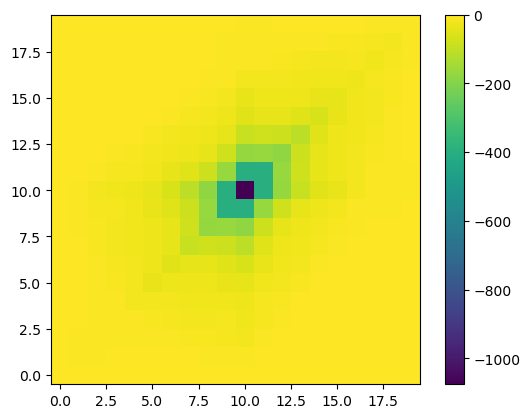

In [8]:
data = V**2 / 2 / T**2 * np.fft.fftshift(s3.T)
plt.imshow(data, origin='lower')
plt.colorbar()

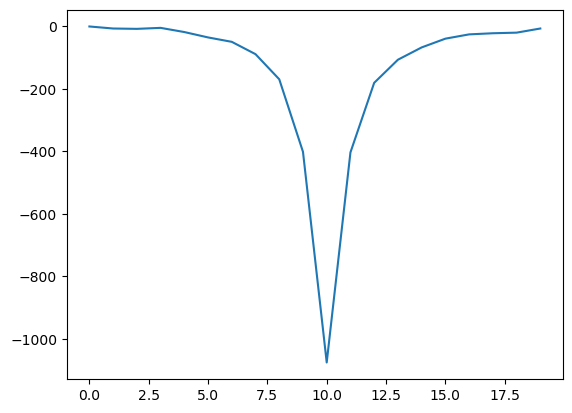

In [9]:
plt.plot([data[i,i] for i in range(2*step_size)])

In [15]:
np.savetxt(path / 'corr3_xx_step10', data)

# t1=t2

## P-wave modulus

In [5]:
data = np.loadtxt(path / 'corr3_xx_step10')

In [10]:
step_size = 10
corr3 = np.array([data[i,i] for i in range(step_size, 2*step_size)])
fluct3 = corr3[0]

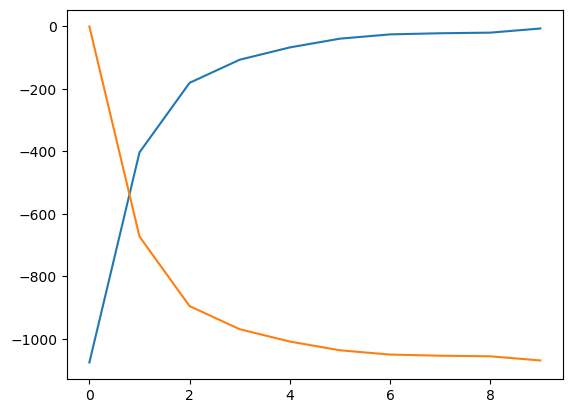

In [25]:
plt.plot(corr3)
plt.plot(fluct3 - corr3)

In [26]:
CBK = observ['CBK']
born_len = len(CBK)

In [36]:
stress_born = observ['stress'][:born_len] - observ['stress'][:born_len].mean(0)

In [39]:
corr2 = 0
step_size = 10
steps = born_len // step_size - 1
chunks = 100
steps_chunk = steps // chunks
print(f"Steps number: {steps}")
for j, _ in enumerate(ProgressBarText(range(chunks), 25)):
    for k in range(steps_chunk):
        i = j * steps_chunk + k
        s = stress_born[i*step_size:(i+1)*step_size, 0, 0].copy()
        C = CBK[i*step_size:(i+1)*step_size, 0, 0, 0, 0].copy()
        corr2 += 3/2*V/T * corr2_fast(C, s).real / steps

Steps number: 999999
Progress: |█████████████████████████| 100.0% Elapsed: 0:00:42, Estimated: 0:00:42


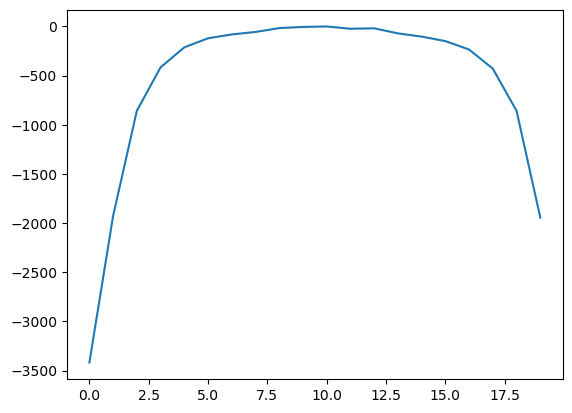

In [40]:
plt.plot(corr2)

In [43]:
corr2 = corr2[:len(corr2)//2]
fluct2 = corr2[0] 

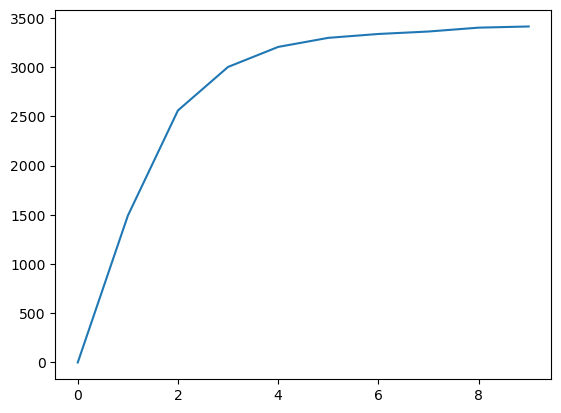

In [44]:
plt.plot(corr2 - fluct2)

In [48]:
mod_t = NBK_avg[0,0,0,0,0,0] + corr2 - fluct2 + fluct3 - corr3

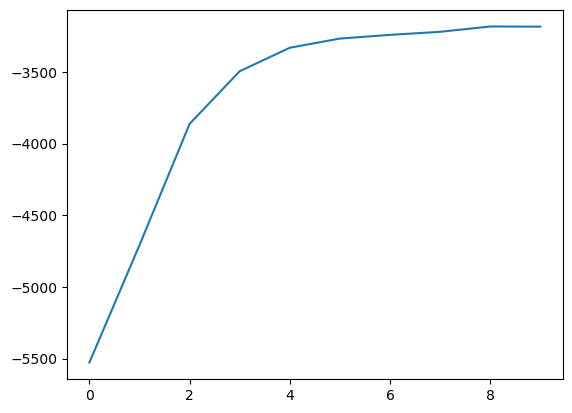

In [49]:
plt.plot(mod_t)

In [50]:
np.savetxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_nonlin_dt0.005', mod_t)